<a href="https://colab.research.google.com/github/ankan-git-coder/computer_vision/blob/main/pytorch_lightning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install watermark

In [7]:
%reload_ext watermark
%watermark -p torch,pytorch_lightning,torchmetrics,matplotlib

torch            : 2.11.0+cu128
pytorch_lightning: unknown
torchmetrics     : unknown
matplotlib       : 3.10.0



In [8]:
BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 0.005
NUM_WORKERS = 4

In [10]:
import torch
import torch.nn.functional as F

In [13]:
# Regular PyTorch Module
class PyTorchModel(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.num_classes = num_classes

        #CALCULATION:
        #(W - K + 2*P)/s +1 = output



        self.features = torch.nn.Sequential(
            # 28x28x1 => 28x28x8
            torch.nn.Conv2d(
                in_channels=1,
                out_channels=8,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding=1),
            torch.nn.ReLU(),

            # 28x28x8 => 14x14x8
            torch.nn.MaxPool2d(
                kernel_size=(2, 2),
                stride=(2, 2),
                padding=0),

            # 14x14x8 => 14x14x16
            torch.nn.Conv2d(
                in_channels=8,
                out_channels=16,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding=1),
            torch.nn.ReLU(),

            # 14x14x16 => 7x7x16
            torch.nn.MaxPool2d(
                kernel_size=(2, 2),
                stride=(2, 2),
                padding=0)
        )

        self.output_layer = torch.nn.Linear(7*7*16, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        return x

In [15]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.2 MB/s eta 0:00:00


In [16]:
import pytorch_lightning as pl
import torchmetrics

In [17]:
class LightningModel(pl.LightningModule):
    def __init__(self,model,learning_rate):
        super().__init__()
        self.learning_rate = learning_rate
        self.model = model
        if hasattr(model, "dropout_proba"):
            self.dropout_proba = model.dropout_proba
        self.save_hyperparameters(ignore=['model'])

        self.train_acc = torchmetrics.Accuracy()
        self.valid_acc = torchmetrics.Accuracy()
        self.test_acc = torchmetrics.Accuracy()
    def forward(self,x):
        return self.model(x)

    def _shared_step(self, batch):
        features, true_labels = batch
        logits = self(features)
        loss = torch.nn.functional.cross_entropy(logits, true_labels)
        predicted_labels = torch.argmax(logits, dim=1)

        return loss, true_labels, predicted_labels

    def training_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("train_loss", loss)

        # Do another forward pass in .eval() mode to compute accuracy
        # while accountingfor Dropout, BatchNorm etc. behavior
        # during evaluation (inference)
        self.model.eval()
        with torch.no_grad():
            _, true_labels, predicted_labels = self._shared_step(batch)
        self.train_acc(predicted_labels, true_labels)
        self.log("train_acc", self.train_acc, on_epoch=True, on_step=False)
        self.model.train()

        return loss  # this is passed to the optimzer for training

    def validation_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("valid_loss", loss)
        self.valid_acc(predicted_labels, true_labels)
        self.log(
            "valid_acc",
            self.valid_acc,
            on_epoch=True,
            on_step=False,
            prog_bar=True,
        )

    def test_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.test_acc(predicted_labels, true_labels)
        self.log("test_acc", self.test_acc, on_epoch=True, on_step=False)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [18]:
from collections import Counter
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [19]:
train_dataset = datasets.MNIST(
    root="./data", train=True, transform=transforms.ToTensor(), download=True
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    drop_last=True,
    shuffle=True,
)

test_dataset = datasets.MNIST(
    root="./data", train=False, transform=transforms.ToTensor()
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    drop_last=False,
    shuffle=False,
)

train_counter = Counter()
for images, labels in train_loader:
    train_counter.update(labels.tolist())

test_counter = Counter()
for images, labels in test_loader:
    test_counter.update(labels.tolist())

print("\nTraining label distribution:")
sorted(train_counter.items())

print("\nTest label distribution:")
sorted(test_counter.items())


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.73MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker crea


Training label distribution:

Test label distribution:


[(0, 980),
 (1, 1135),
 (2, 1032),
 (3, 1010),
 (4, 982),
 (5, 892),
 (6, 958),
 (7, 1028),
 (8, 974),
 (9, 1009)]

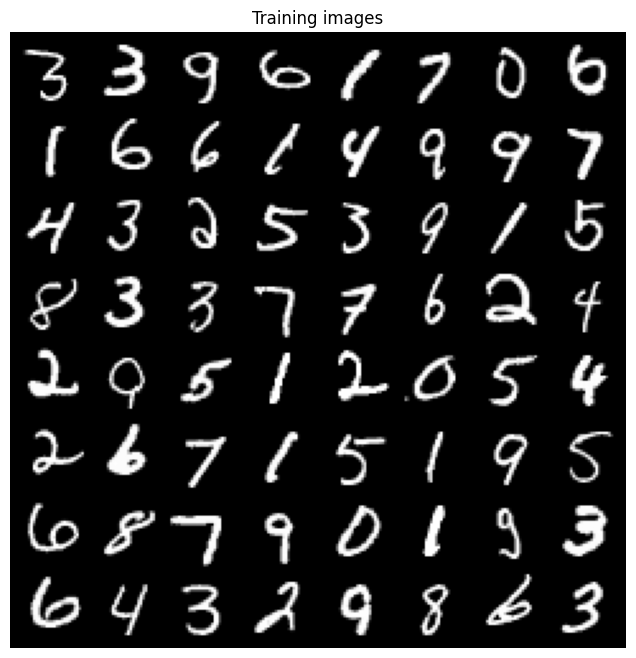

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torchvision


for images, labels in train_loader:
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64],
    padding=2,
    normalize=True),
    (1, 2, 0)))
plt.show()